# Cycling Traffic - EDA & Baseline

Loads the merged panel from `02_build_panel.py`, applies the
2023 / 2024 / 2025 split from `split.py`, explores the train set,
and trains a Random Forest baseline.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'Predictive model':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from download_data import ensure_data
from split import temporal_split, TRAIN_YEAR, VAL_YEAR, TEST_YEAR

ensure_data(['panel_merged.parquet', 'shap_values.pkl'])

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')


## 1. Load panel and apply temporal split

In [4]:

panel = pd.read_parquet(ROOT / 'data' / 'panel_merged.parquet')
print(f'Panel total: {len(panel):,} rows, {panel["site_id"].nunique()} sites')
print(f'Date range:  {panel["datetime"].min()}  ->  {panel["datetime"].max()}')

train, val, test = temporal_split(panel)
print(f'
Train ({TRAIN_YEAR}): {len(train):,} rows, {train["site_id"].nunique()} sites')
print(f'Val   ({VAL_YEAR}): {len(val):,} rows, {val["site_id"].nunique()} sites')
print(f'Test  ({TEST_YEAR}): {len(test):,} rows, {test["site_id"].nunique()} sites')


Panel total: 9,831,870 rows, 150 sites
Date range:  2019-08-01 00:00:00  ->  2025-12-31 23:00:00

Train (2023): 2,397,410 rows, 141 sites
Val   (2024): 2,419,596 rows, 141 sites
Test  (2025): 2,474,350 rows, 147 sites


## 2. Data quality (train set)

In [5]:
miss = train['cyclist_count'].isna().sum()
zeros = (train['cyclist_count'] == 0).sum()
print(f'cyclist_count -- missing: {miss:,}  |  zeros: {zeros:,} ({zeros/len(train)*100:.1f}%)')
print(f'temp_c missing rate:        {train["temp_c"].isna().mean()*100:.2f}%')
print(f'road_bearing missing rate:  {train["road_bearing"].isna().mean()*100:.2f}%')
print(f'\nIN/OUT distribution:')
print(train['richting'].value_counts().to_string())

cyclist_count -- missing: 0  |  zeros: 898,072 (37.5%)
temp_c missing rate:        0.00%
road_bearing missing rate:  2.19%

IN/OUT distribution:
richting
IN     1198705
OUT    1198705


## 3. Station map

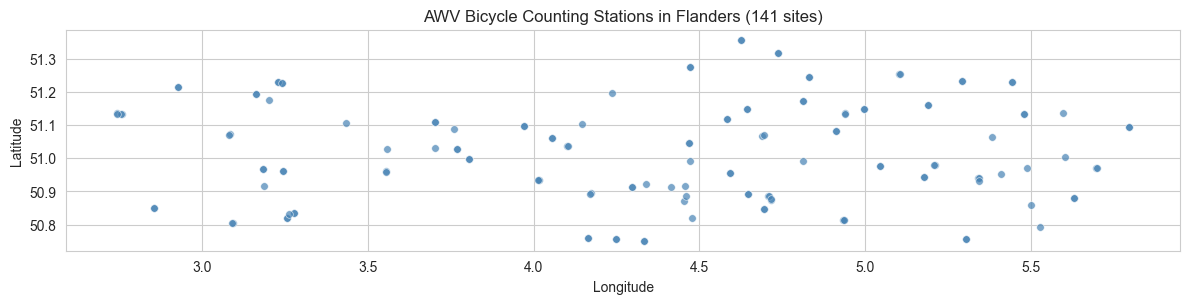

In [6]:
sites = train.groupby('site_id')[['lat','long','naam']].first().reset_index()
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(sites['long'], sites['lat'], c='steelblue', s=30,
           alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'AWV Bicycle Counting Stations in Flanders ({len(sites)} sites)')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

## 4. Temporal patterns (train set)

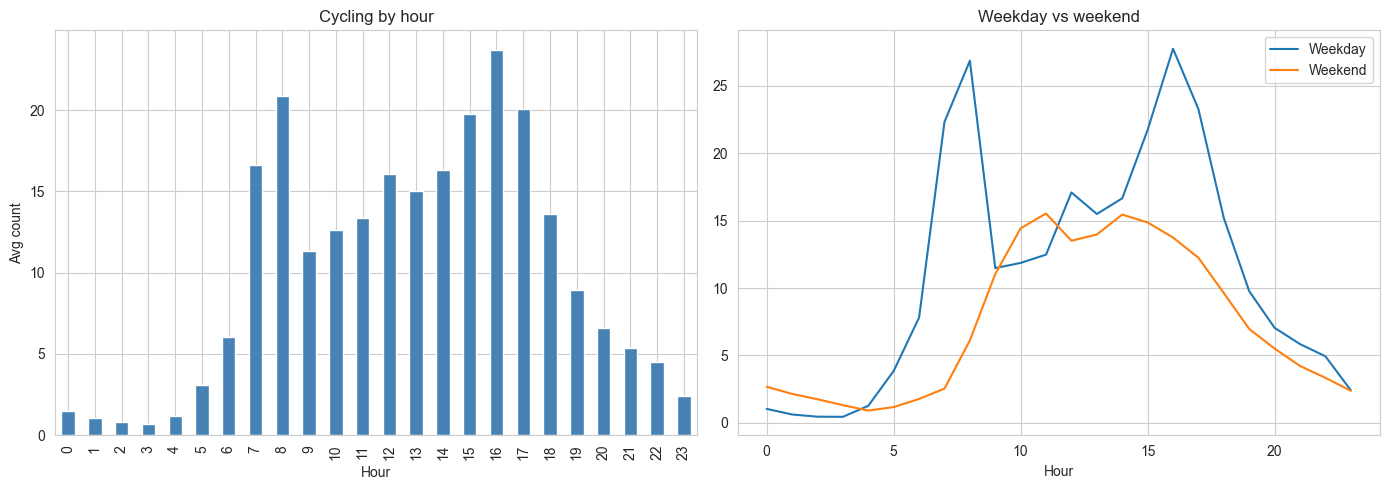

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train.groupby('hour')['cyclist_count'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Avg count')
axes[0].set_title('Cycling by hour')

hwe = train.groupby(['hour','is_weekend'])['cyclist_count'].mean().unstack()
hwe.columns = ['Weekday','Weekend']
hwe.plot(ax=axes[1])
axes[1].set_xlabel('Hour'); axes[1].set_title('Weekday vs weekend')

plt.tight_layout(); plt.show()

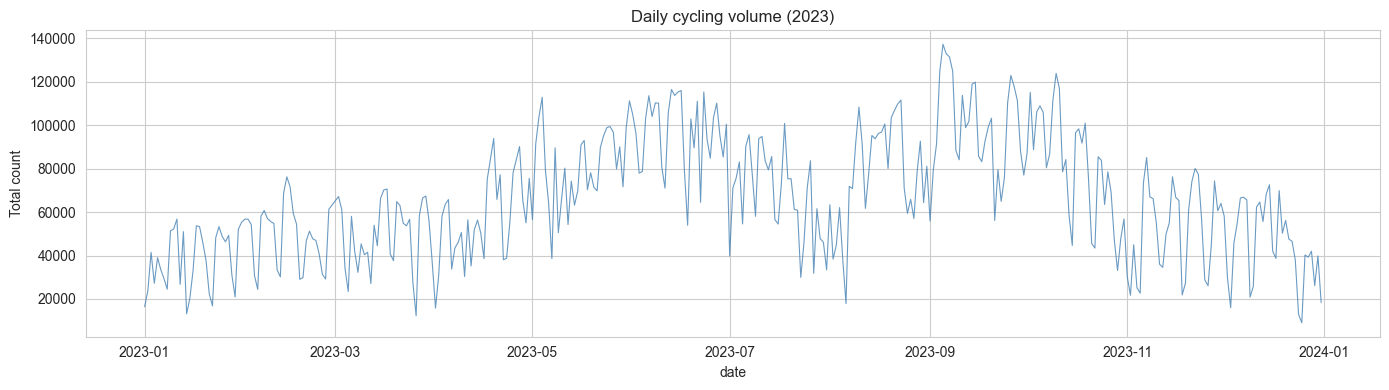

In [8]:
daily = train.groupby('date')['cyclist_count'].sum()
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, linewidth=0.8, alpha=0.8, color='steelblue')
ax.set_ylabel('Total count'); ax.set_title(f'Daily cycling volume ({TRAIN_YEAR})')
plt.tight_layout(); plt.show()

## 5. Top stations

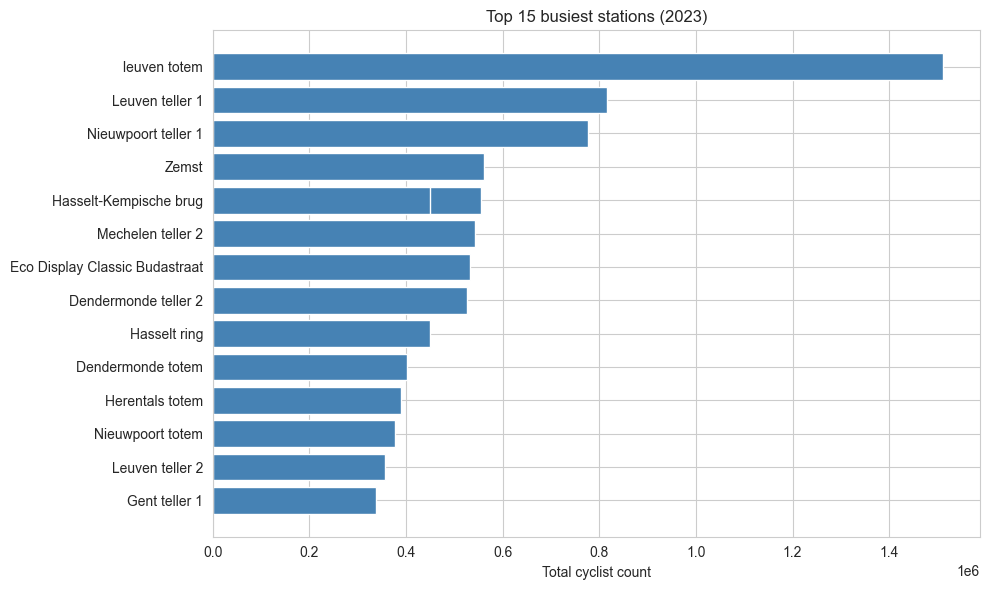

In [9]:
top = (train.groupby(['site_id','naam'])['cyclist_count']
       .sum().sort_values(ascending=False).head(15).reset_index())
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['naam'], top['cyclist_count'], color='steelblue')
ax.set_xlabel('Total cyclist count'); ax.set_title(f'Top 15 busiest stations ({TRAIN_YEAR})')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Weather correlations (Spearman, train set)

temp_c               r=+0.213 ***
humidity             r=-0.262 ***
precip_mm            r=-0.027 ***
rain_mm              r=-0.026 ***
windspeed_kmh        r=-0.010 ***
windgust_kmh         r=+0.050 ***
cloudcover_pct       r=-0.039 ***
pressure_hpa         r=+0.054 ***
wind_impact          r=-0.009 ***


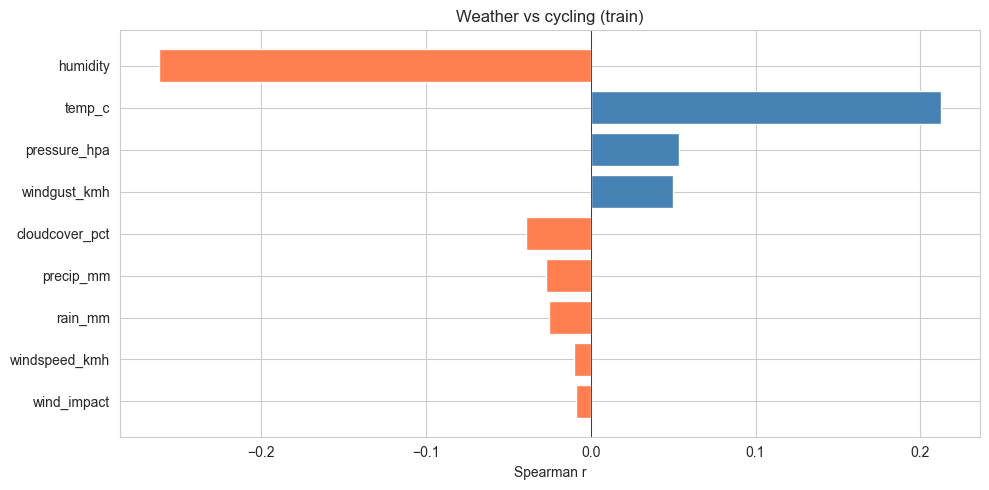

In [10]:
wvars = ['temp_c','humidity','precip_mm','rain_mm',
         'windspeed_kmh','windgust_kmh','cloudcover_pct','pressure_hpa','wind_impact']
rows = []
for v in wvars:
    sub = train[[v, 'cyclist_count']].dropna()
    r, p = spearmanr(sub[v], sub['cyclist_count'])
    rows.append({'variable': v, 'r': r})
    print(f'{v:20s} r={r:+.3f} {"***" if p<0.001 else ""}')

cdf = pd.DataFrame(rows).sort_values('r', key=abs, ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cdf['variable'], cdf['r'],
        color=['steelblue' if r>0 else 'coral' for r in cdf['r']])
ax.set_xlabel('Spearman r'); ax.set_title('Weather vs cycling (train)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

# 7. Random Forest Models

### 7.1 Baseline Random Forest (20 Features)

In [20]:
fcols = [
    'site_id','hour','day_of_week','month',
    'is_holiday','days_to_nearest_holiday','is_in',
    'temp_c','humidity','dewpoint_c','precip_mm','rain_mm','snowfall_cm',
    'windspeed_kmh','winddir_deg','windgust_kmh',
    'lat','long','road_bearing','wind_impact',
]

# drop val/test rows for stations not seen in train (1 in 2024, 9 in 2025)
train_sites = set(train['site_id'].unique())
new_in_val  = sorted(set(val['site_id'].unique()) - train_sites)
new_in_test = sorted(set(test['site_id'].unique()) - train_sites)
print('new in val:',  new_in_val)
print('new in test:', new_in_test)
val  = val[val['site_id'].isin(train_sites)].copy()
test = test[test['site_id'].isin(train_sites)].copy()

def prep(df):
    out = df.dropna(subset=['cyclist_count']).copy()
    out['road_bearing'] = out['road_bearing'].fillna(-1)
    out['wind_impact']  = out['wind_impact'].fillna(0)
    return out

tr, va, te = prep(train), prep(val), prep(test)
X_tr, y_tr = tr[fcols], tr['cyclist_count']
X_va, y_va = va[fcols], va['cyclist_count']
X_te, y_te = te[fcols], te['cyclist_count']

print(f'\nFeatures: {len(fcols)}')
print(f'Train: {len(X_tr):,}  Val: {len(X_va):,}  Test: {len(X_te):,}')

# Random Forest. max_samples=0.3 keeps fitting fast on 2.4M rows.
model = RandomForestRegressor(n_estimators=100, max_depth=20,
                              max_samples=0.3, random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)

for label, X, y in [('Train', X_tr, y_tr), ('Val  ', X_va, y_va), ('Test ', X_te, y_te)]:
    p = np.clip(model.predict(X), 0, None)
    print(f'  {label}: MAE={mean_absolute_error(y,p):.2f}  '
          f'RMSE={np.sqrt(mean_squared_error(y,p)):.2f}  '
          f'R2={r2_score(y,p):+.3f}')

# Preserve the no-lag model for the interpretability/SHAP section.
baseline_model = model
baseline_fcols = fcols.copy()
baseline_y_te = y_te.copy()


new in val: []
new in test: []

Features: 20
Train: 2,397,410  Val: 2,416,668  Test: 2,395,134
  Train: MAE=3.37  RMSE=8.10  R2=+0.892
  Val  : MAE=4.72  RMSE=15.44  R2=+0.679
  Test : MAE=5.62  RMSE=16.44  R2=+0.649


### feature importance

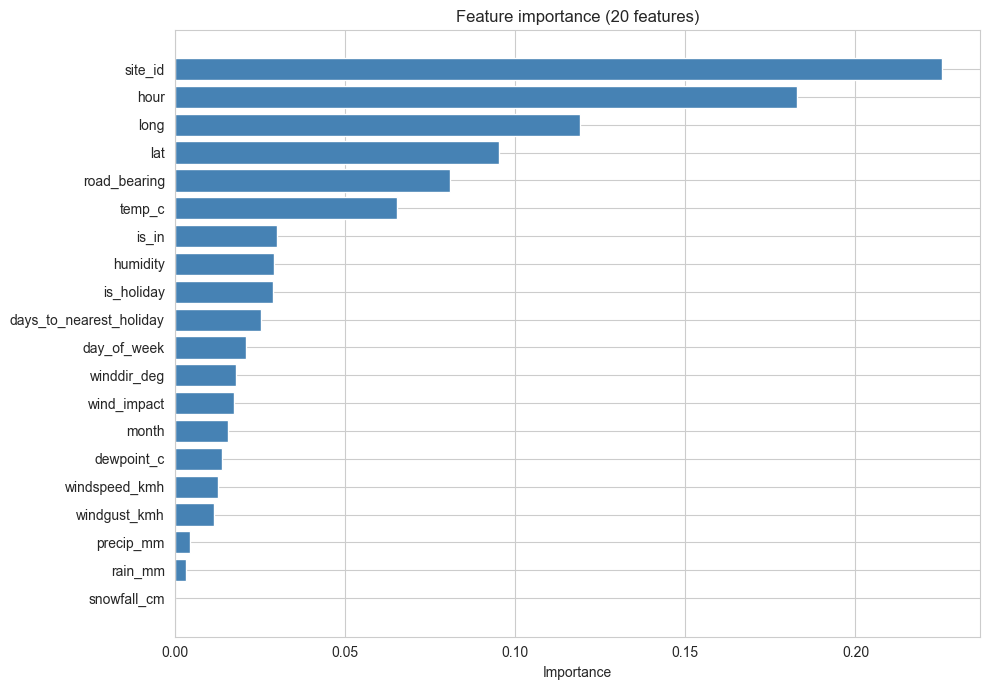

In [21]:
imp = (pd.DataFrame({'f': fcols, 'i': model.feature_importances_})
       .sort_values('i', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp['f'], imp['i'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Feature importance (20 features)')
plt.tight_layout()
plt.show()

### 7.2 Random Forest with Lag-24h Feature (21 Features)

In [13]:
fcols = [
    'site_id','hour','day_of_week','month',
    'is_holiday','days_to_nearest_holiday','is_in',
    'temp_c','humidity','dewpoint_c','precip_mm','rain_mm','snowfall_cm',
    'windspeed_kmh','winddir_deg','windgust_kmh',
    'lat','long','road_bearing','wind_impact','lag_24h_count',
]

def add_lag_24h(panel):
    lag_src = panel[['site_id', 'richting', 'datetime', 'cyclist_count']].copy()
    lag_src['datetime'] = lag_src['datetime'] + pd.Timedelta(days=1)
    lag_src = lag_src.rename(columns={'cyclist_count': 'lag_24h_count'})
    out = panel.merge(lag_src, on=['site_id', 'richting', 'datetime'], how='left')
    out['lag_24h_count'] = out['lag_24h_count'].fillna(0)
    return out

panel = add_lag_24h(panel)
train, val, test = temporal_split(panel)

train_sites = set(train['site_id'].unique())
new_in_val  = sorted(set(val['site_id'].unique()) - train_sites)
new_in_test = sorted(set(test['site_id'].unique()) - train_sites)
print('new in val:',  new_in_val)
print('new in test:', new_in_test)
val  = val[val['site_id'].isin(train_sites)].copy()
test = test[test['site_id'].isin(train_sites)].copy()

def prep(df):
    out = df.dropna(subset=['cyclist_count']).copy()
    out['road_bearing'] = out['road_bearing'].fillna(-1)
    out['wind_impact']  = out['wind_impact'].fillna(0)
    return out

tr, va, te = prep(train), prep(val), prep(test)
X_tr, y_tr = tr[fcols], tr['cyclist_count']
X_va, y_va = va[fcols], va['cyclist_count']
X_te, y_te = te[fcols], te['cyclist_count']

print(f'Features: {len(fcols)}')
print(f'Train: {len(X_tr):,}  Val: {len(X_va):,}  Test: {len(X_te):,}')

model = RandomForestRegressor(n_estimators=100, max_depth=20,
                              max_samples=0.3, random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)

for label, X, y in [('Train', X_tr, y_tr), ('Val  ', X_va, y_va), ('Test ', X_te, y_te)]:
    p = np.clip(model.predict(X), 0, None)
    print(f'  {label}: MAE={mean_absolute_error(y,p):.2f}  '
          f'RMSE={np.sqrt(mean_squared_error(y,p)):.2f}  '
          f'R2={r2_score(y,p):+.3f}')

new in val: [np.int64(123)]
new in test: [np.int64(123), np.int64(145), np.int64(146), np.int64(147), np.int64(148), np.int64(149), np.int64(150), np.int64(151), np.int64(152)]
Features: 21
Train: 2,397,410  Val: 2,416,668  Test: 2,395,134
  Train: MAE=3.37  RMSE=8.42  R2=+0.883
  Val  : MAE=4.54  RMSE=14.73  R2=+0.708
  Test : MAE=4.89  RMSE=13.05  R2=+0.779


### feature importance

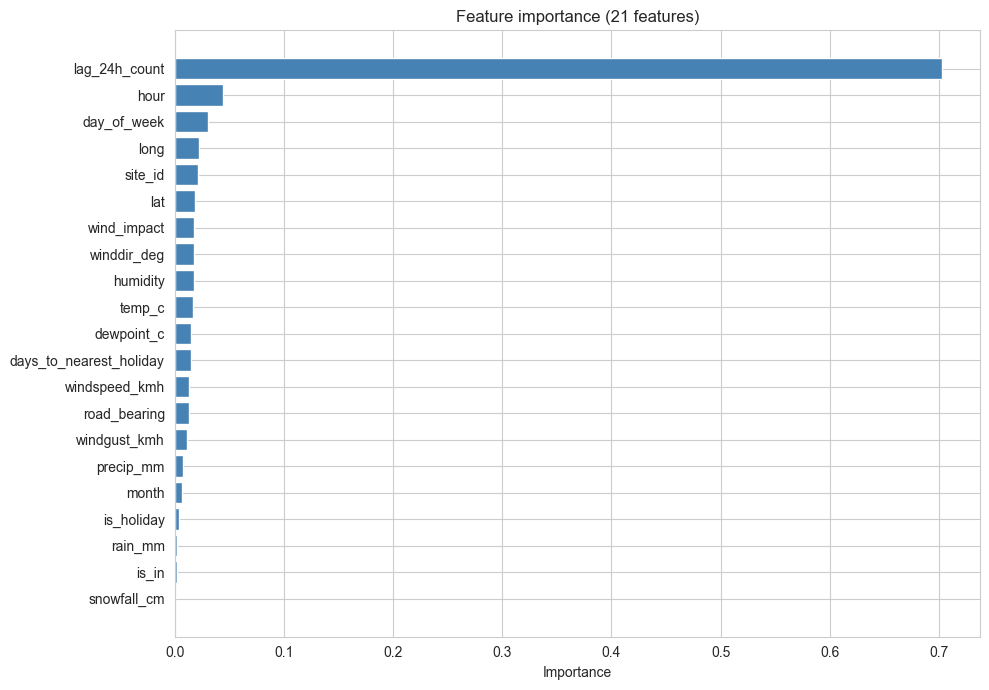

In [17]:
imp = (pd.DataFrame({'f': fcols, 'i': model.feature_importances_})
       .sort_values('i', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp['f'], imp['i'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Feature importance (21 features)')
plt.tight_layout()
plt.show()

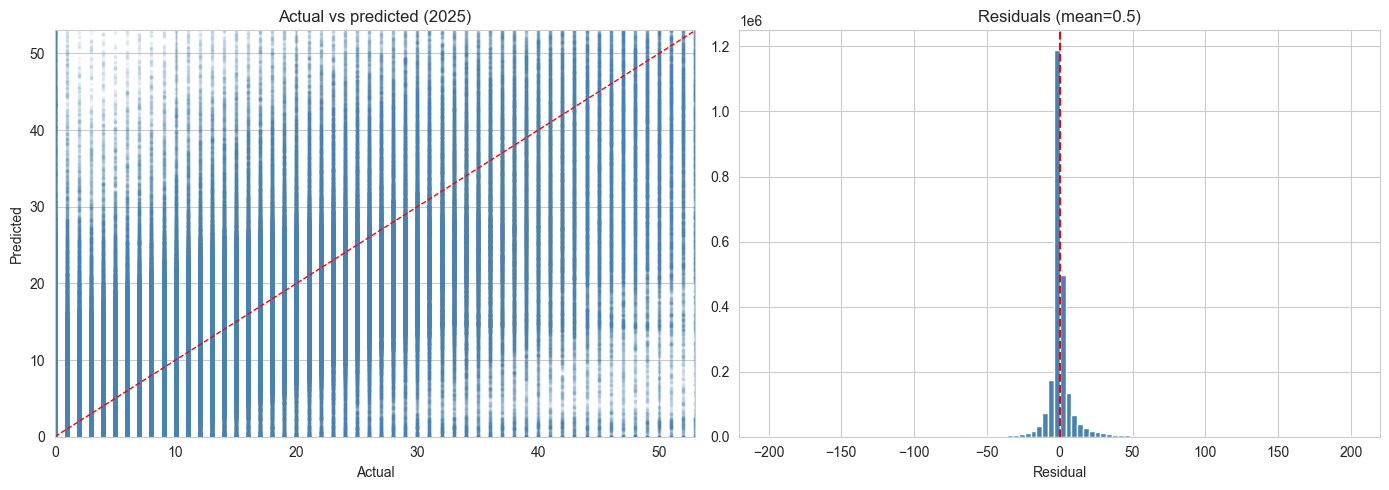

In [114]:
y_te_pr = np.clip(model.predict(X_te), 0, None)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = int(np.percentile(y_te, 95))
axes[0].scatter(y_te, y_te_pr, alpha=0.05, s=3, color='steelblue')
axes[0].plot([0, p95], [0, p95], 'r--', lw=1)
axes[0].set_xlim(0, p95); axes[0].set_ylim(0, p95)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Actual vs predicted ({TEST_YEAR})')

resid = y_te - y_te_pr
axes[1].hist(resid.clip(-200, 200), bins=100, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Residual'); axes[1].set_title(f'Residuals (mean={resid.mean():.1f})')

plt.tight_layout(); plt.show()

## 8. SHAP Analysis (20-Feature Baseline Model)

In [ ]:

import shap
print(shap.__version__)


In [116]:
import pickle

with open(ROOT / 'data' / 'shap_values.pkl', 'rb') as f:
    cache = pickle.load(f)

shap_values = cache['shap_values']
X_shap = cache['sample']
expected_value = cache['expected_value']
if np.ndim(expected_value) > 0:
    expected_value = float(np.ravel(expected_value)[0])

cache_features = list(cache.get('feature_columns', X_shap.columns))
if cache_features != baseline_fcols:
    raise ValueError(
        'The loaded SHAP cache does not match the 20-feature no-lag baseline. '
        'Regenerate it with src/cache_shap.py or replace data/shap_values.pkl '
        'with the baseline no-lag SHAP cache before running this section.'
    )

X_shap = X_shap[baseline_fcols]
print(f'Loaded no-lag SHAP cache: {X_shap.shape[0]:,} rows, {X_shap.shape[1]} features')


### 8.1 Global Feature Importance

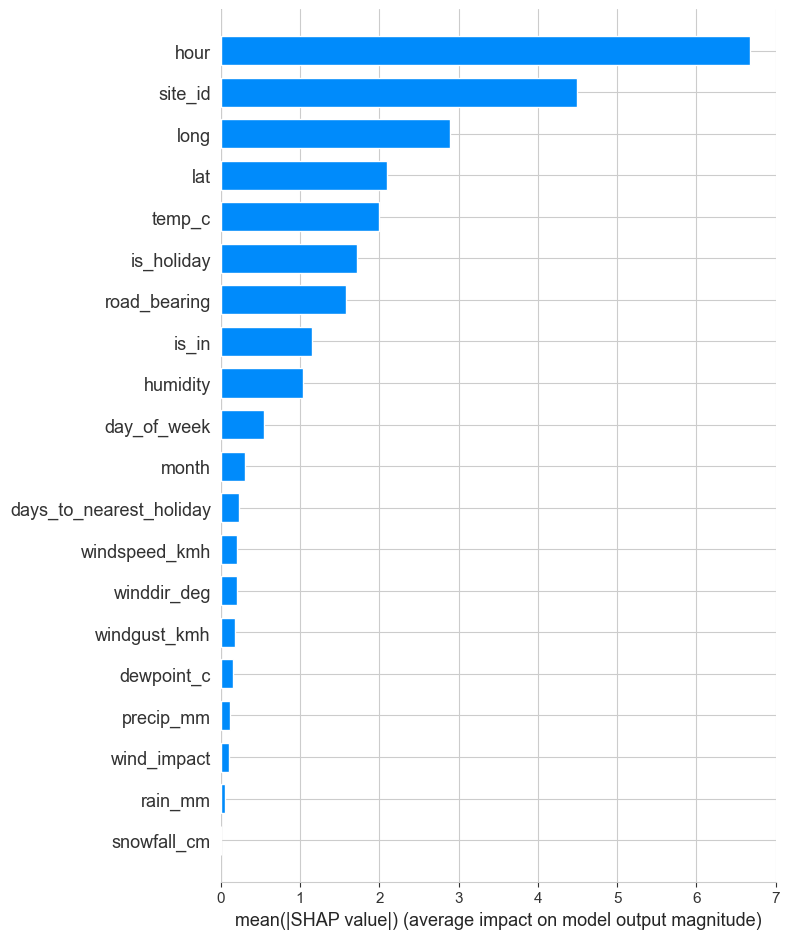

In [117]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

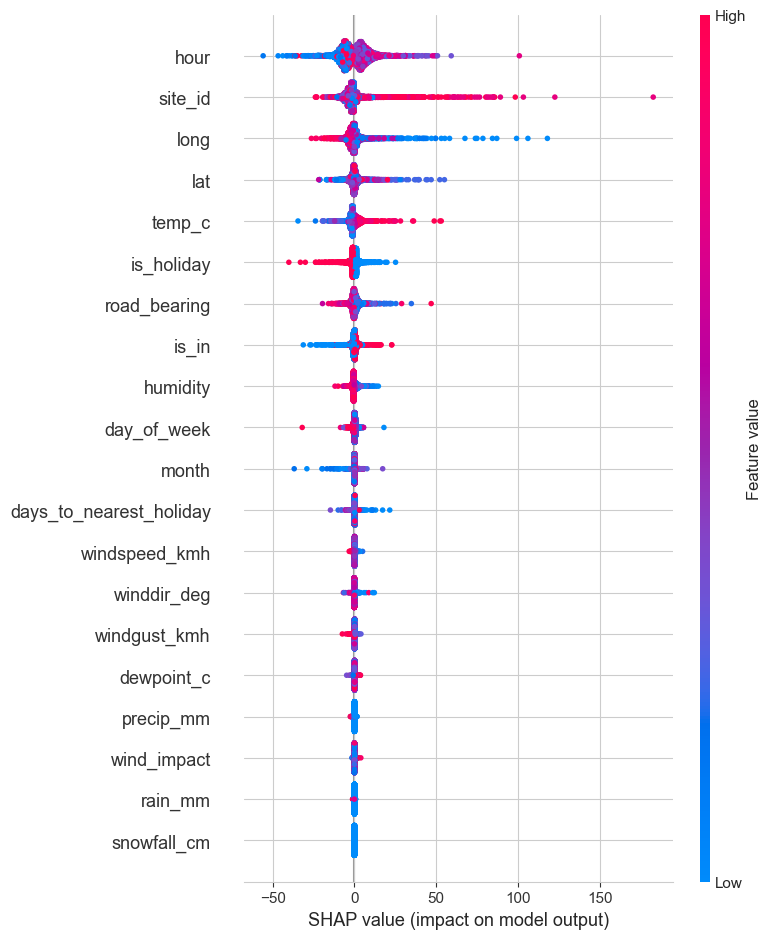

In [118]:
shap.summary_plot(
    shap_values,
    X_shap
)

### 8.2 Feature Effect Analysis

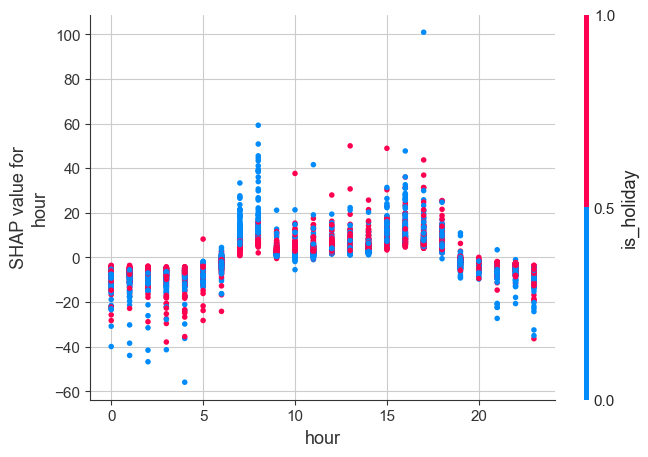

In [119]:
shap.dependence_plot(
    "hour",
    shap_values,
    X_shap
)

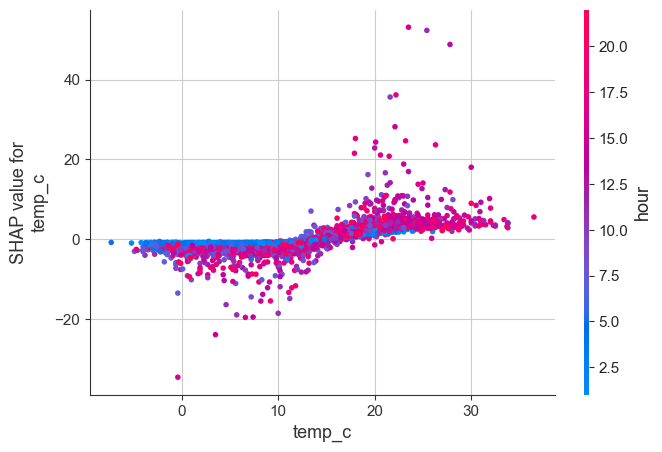

In [120]:
shap.dependence_plot(
    "temp_c",
    shap_values,
    X_shap
)

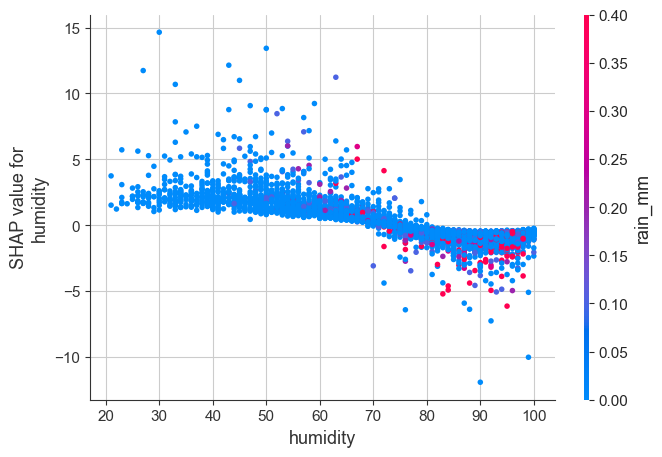

In [121]:
shap.dependence_plot(
    "humidity",
    shap_values,
    X_shap
)

In [124]:

sample_cases = pd.DataFrame({
    'actual': baseline_y_te.loc[X_shap.index],
    'predicted': baseline_model.predict(X_shap[baseline_fcols])
})

sample_cases['error'] = (
    sample_cases['predicted'] - sample_cases['actual']
).abs()

sample_cases.head()


,actual,predicted,error
725094,0.0,5.666007,5.666007
7356023,5.0,4.748884,0.251116
8817661,0.0,2.214775,2.214775
2229493,10.0,5.504037,4.495963
9012786,4.0,7.028403,3.028403


In [125]:
sample_cases.sort_values(
    "actual",
    ascending=False
).head(10)

,actual,predicted,error
7934926,496.0,386.302954,109.697046
5334063,322.0,191.246452,130.753548
5302504,284.0,243.613948,40.386052
9762533,272.0,131.377000,140.623000
8644896,268.0,182.897183,85.102817
5301614,247.0,262.661524,15.661524
7999101,225.0,57.423487,167.576513
5428442,222.0,147.462483,74.537517
7937826,219.0,204.345489,14.654511
9622956,207.0,204.277475,2.722525


### 8.3 Normal Prediction Case

In [128]:
sample_cases.sort_values("error").head(20)

,actual,predicted,error
8677515,0.0,0.000000,0.000000
9453427,0.0,0.000000,0.000000
9419378,0.0,0.000000,0.000000
7786497,0.0,0.000539,0.000539
7780352,0.0,0.000761,0.000761
7786040,0.0,0.000761,0.000761
9676240,0.0,0.000777,0.000777
4624891,13.0,12.998973,0.001027
8562472,0.0,0.001172,0.001172
7725952,0.0,0.001413,0.001413


In [129]:
case_idx = 4624891
X_shap.loc[case_idx]

site_id                     53.000000
hour                         9.000000
day_of_week                  4.000000
month                        2.000000
is_holiday                   0.000000
days_to_nearest_holiday     44.000000
is_in                        0.000000
temp_c                      -2.000000
humidity                    89.000000
dewpoint_c                  -3.500000
precip_mm                    0.000000
rain_mm                      0.000000
snowfall_cm                  0.000000
windspeed_kmh                9.800000
winddir_deg                110.000000
windgust_kmh                17.300000
lat                         51.230230
long                         3.228000
road_bearing               276.732921
wind_impact                 -0.973311
Name: 4624891, dtype: float64

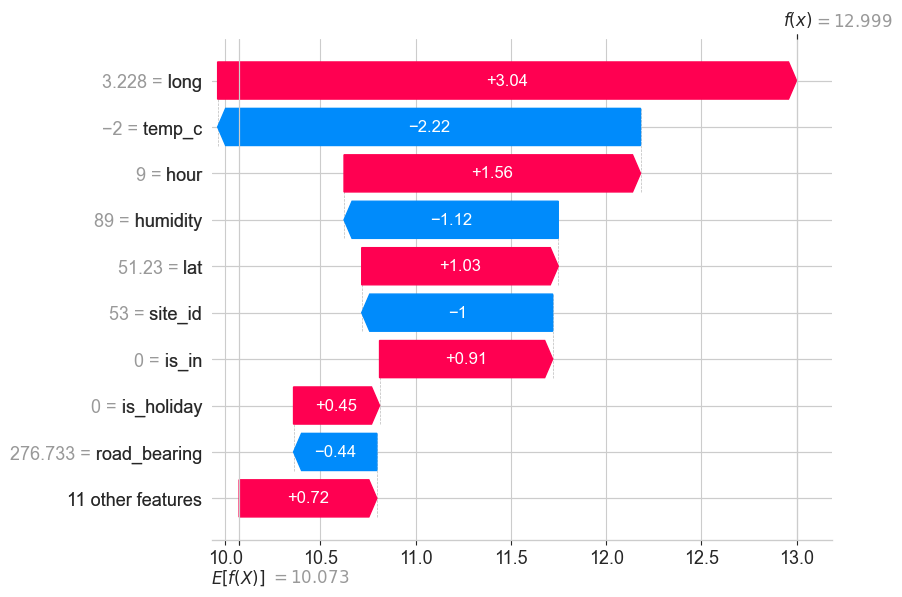

In [130]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[
            X_shap.index.get_loc(case_idx)
        ],
base_values=expected_value,
        data=X_shap.loc[case_idx],
        feature_names=X_shap.columns
    )
)


### 8.4 Over-Prediction Case Study

In [134]:
sample_cases.sort_values(
    "error",
    ascending=False
).head(10)

,actual,predicted,error
9765413,0.0,198.870000,198.870000
7999101,225.0,57.423487,167.576513
8821538,0.0,153.796434,153.796434
9622261,189.0,37.216667,151.783333
9548382,148.0,2.550000,145.450000
8985860,147.0,1.989053,145.010947
9762533,272.0,131.377000,140.623000
9745054,0.0,139.905000,139.905000
5334063,322.0,191.246452,130.753548
9765456,0.0,123.210000,123.210000


In [135]:
case_idx = 9765413
X_shap.loc[case_idx]

site_id                    143.000000
hour                        17.000000
day_of_week                  4.000000
month                        8.000000
is_holiday                   1.000000
days_to_nearest_holiday      0.000000
is_in                        0.000000
temp_c                      26.300000
humidity                    49.000000
dewpoint_c                  14.800000
precip_mm                    0.000000
rain_mm                      0.000000
snowfall_cm                  0.000000
windspeed_kmh               16.000000
winddir_deg                348.000000
windgust_kmh                41.400000
lat                         50.830660
long                         3.262860
road_bearing               240.389955
wind_impact                 -0.302537
Name: 9765413, dtype: float64

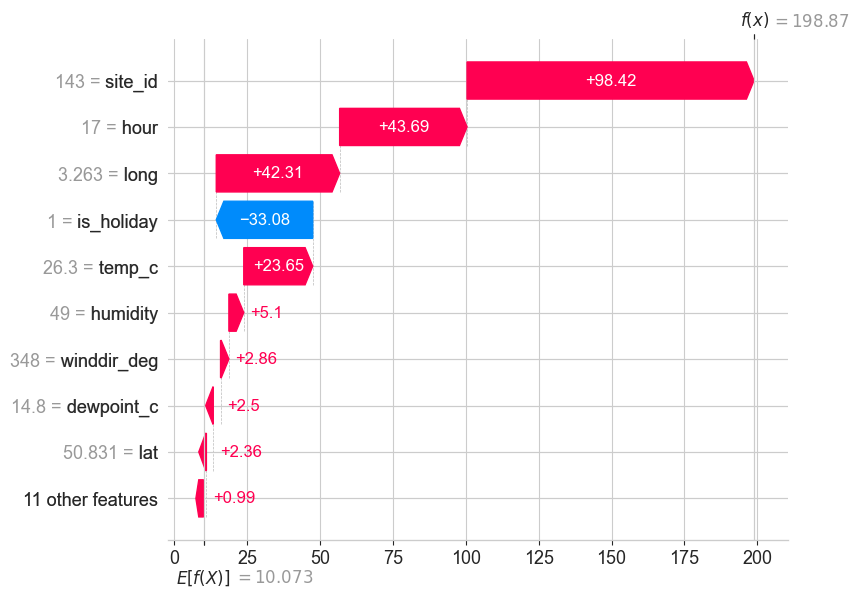

In [137]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[X_shap.index.get_loc(case_idx)],
base_values=expected_value,
        data=X_shap.loc[case_idx],
        feature_names=X_shap.columns
    )
)


### 8.5 Under-Prediction Case Study

In [138]:
sample_cases["residual"] = (
    sample_cases["predicted"]
    - sample_cases["actual"]
)

sample_cases.sort_values("residual").head(10)

,actual,predicted,error,residual
7999101,225.0,57.423487,167.576513,-167.576513
9622261,189.0,37.216667,151.783333,-151.783333
9548382,148.0,2.550000,145.450000,-145.450000
8985860,147.0,1.989053,145.010947,-145.010947
9762533,272.0,131.377000,140.623000,-140.623000
5334063,322.0,191.246452,130.753548,-130.753548
8983483,120.0,3.421979,116.578021,-116.578021
7934926,496.0,386.302954,109.697046,-109.697046
8986797,107.0,1.743002,105.256998,-105.256998
9621460,102.0,0.000000,102.000000,-102.000000


In [139]:
case_idx = 7999101
X_shap.loc[case_idx]

site_id                    108.000000
hour                        18.000000
day_of_week                  1.000000
month                       10.000000
is_holiday                   0.000000
days_to_nearest_holiday     11.000000
is_in                        1.000000
temp_c                      13.700000
humidity                    73.000000
dewpoint_c                   8.900000
precip_mm                    0.000000
rain_mm                      0.000000
snowfall_cm                  0.000000
windspeed_kmh               14.200000
winddir_deg                201.000000
windgust_kmh                29.900000
lat                         50.847173
long                         4.695467
road_bearing               105.937537
wind_impact                 -0.088242
Name: 7999101, dtype: float64

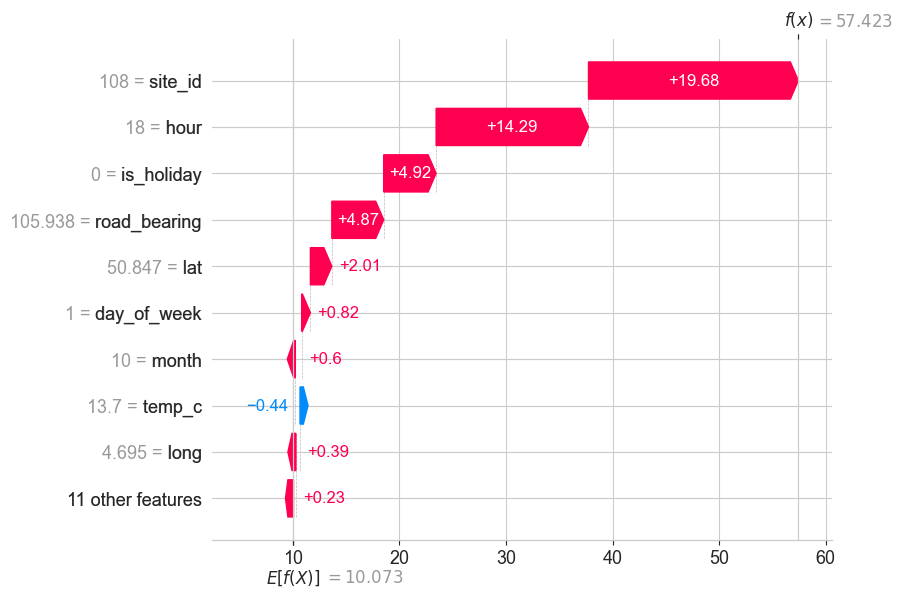

In [141]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[X_shap.index.get_loc(case_idx)],
base_values=expected_value,
        data=X_shap.loc[case_idx],
        feature_names=X_shap.columns
    )
)


## Summary

Train on 2023 (141 stations, ~2.4M hourly rows), validate on 2024, test on 2025.
2019-2022 was dropped because most stations were not yet installed.
Stations that first appear after 2023 (1 in val, 9 in test) are excluded
from evaluation since the model has never seen them.

Random Forest is used as the predictive model.

All merge and cleaning logic lives in `src/02_build_panel.py`; this notebook only loads the parquet and explores.